# B-01｜rPPG 訊號處理：合成訊號驗證

**這份 notebook 不需要任何影片、攝影機或 MediaPipe。**

目的是用一段「已知心率」的合成訊號，把 Track 2 的訊號處理管線跑一遍，
親眼看到每一步做了什麼、以及最後算回來的心率準不準。

真實影片跑不出正確心率時，先回來看這裡：
如果合成訊號是準的，問題就出在錄影條件或 ROI 定位，不是訊號處理本身。

管線：`detrend_signal` → `bandpass_filter` → `estimate_heart_rate`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

import config
from track2_rppg import signal_utils as su

# matplotlib 預設字型沒有中文，圖上的標題會變成方框。
# 挑一個系統裝得到的中文字型；找不到就退回英文標籤也還能看。
from matplotlib import font_manager

available = {f.name for f in font_manager.fontManager.ttflist}
for candidate in ("Microsoft JhengHei", "Microsoft YaHei", "PingFang TC", "Noto Sans CJK TC", "SimHei"):
    if candidate in available:
        # 中文字型擺第一，DejaVu Sans 墊底 —— 中文字型多半沒有 U+2212（數學負號），
        # 只放一個字型的話座標軸的負數刻度會變成方框。
        plt.rcParams["font.sans-serif"] = [candidate, "DejaVu Sans"]
        print(f"中文字型：{candidate}")
        break
else:
    print("找不到中文字型，圖上的中文可能顯示為方框")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print(f"帶通範圍：{config.RPPG_BAND_LOW}-{config.RPPG_BAND_HIGH} Hz "
      f"（{config.RPPG_BAND_LOW * 60:.0f}-{config.RPPG_BAND_HIGH * 60:.0f} bpm）")
print(f"SNR 門檻：{config.RPPG_SNR_MIN} dB")

中文字型：Microsoft JhengHei
帶通範圍：0.7-4.0 Hz （42-240 bpm）
SNR 門檻：3.0 dB


## 1. 合成一段「已知心率」的訊號

我們要模擬的是：**額頭 ROI 的綠通道平均值隨時間的變化**。

真實錄影裡這條曲線由三樣東西疊成，這裡照著造：

| 成分 | 幅度 | 對應真實世界的什麼 |
|---|---|---|
| 心跳正弦波 | 1.0 | 血紅素隨心跳週期改變對綠光的吸收 |
| 線性漂移 | 8.0 | 人緩慢前後移動、環境光變化 |
| 高斯雜訊 | 0.3 | 感測器雜訊、影片壓縮假影 |

基線設 120（8-bit 影像通道平均值的典型量級）。

**注意心跳的幅度只佔基線的 1% 不到，漂移卻是心跳的 8 倍。**
這就是 rPPG 的難處：要找的訊號被比它大一個數量級的干擾蓋住。

In [2]:
TARGET_BPM = 72.0
FPS = 30.0
DURATION_SEC = 20.0

rng = np.random.default_rng(42)
t = np.arange(0.0, DURATION_SEC, 1.0 / FPS)

heartbeat = np.sin(2.0 * np.pi * (TARGET_BPM / 60.0) * t)
drift = 8.0 * t / DURATION_SEC
noise = rng.normal(0.0, 0.3, size=len(t))

raw = 120.0 + heartbeat + drift + noise

print(f"目標心率  ：{TARGET_BPM} bpm = {TARGET_BPM / 60:.3f} Hz")
print(f"取樣率    ：{FPS} fps")
print(f"長度      ：{DURATION_SEC} 秒，共 {len(raw)} 格")
print(f"頻譜解析度：{1 / DURATION_SEC:.4f} Hz = {60 / DURATION_SEC:.1f} bpm")
print(f"訊號範圍  ：{raw.min():.2f} ~ {raw.max():.2f}")

目標心率  ：72.0 bpm = 1.200 Hz
取樣率    ：30.0 fps
長度      ：20.0 秒，共 600 格
頻譜解析度：0.0500 Hz = 3.0 bpm
訊號範圍  ：119.03 ~ 128.99


## 2. 原始訊號長什麼樣

**這一格的重點：你應該看不出心跳。**

PLAN.md 也特別提醒過這件事 —— 第一次跑真實影片看到一條像雜訊的曲線時，
不要以為做錯了。心跳被漂移壓在下面，要到濾波後才會現形。

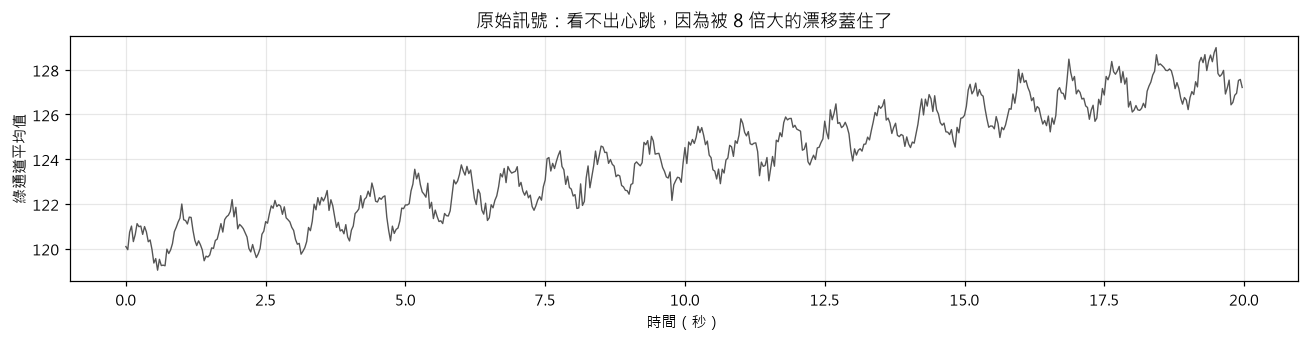

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(t, raw, lw=0.9, color="#555")
ax.set_title("原始訊號：看不出心跳，因為被 8 倍大的漂移蓋住了")
ax.set_xlabel("時間（秒）")
ax.set_ylabel("綠通道平均值")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 第一步：去漂移（detrend）

`scipy.signal.detrend` 對整條訊號做最小平方法擬合一條直線再扣掉。

漂移的能量集中在極低頻（趨近 0 Hz），功率遠大於心跳。
不先扣掉的話，後面的頻譜會被它主導，找不到心跳那個峰。

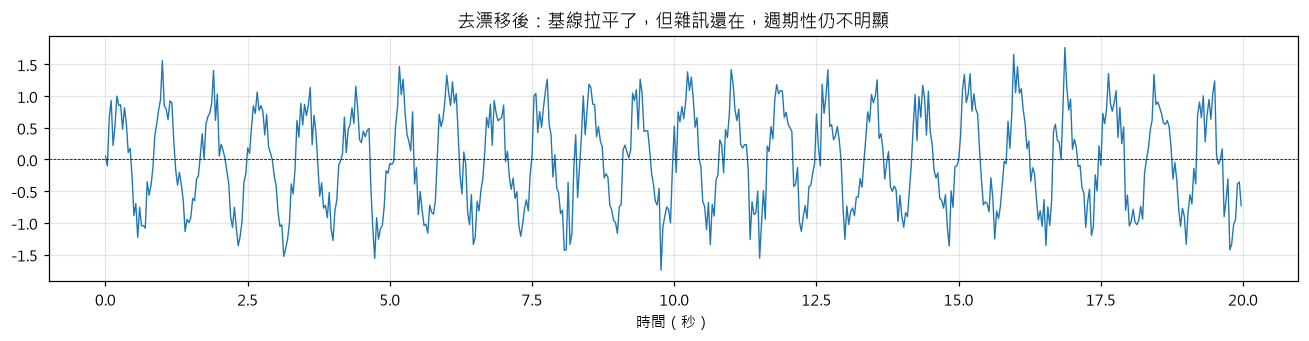

去漂移前的斜率：+0.3954 /秒
去漂移後的斜率：+2.37e-15 /秒


In [4]:
detrended = su.detrend_signal(raw)

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(t, detrended, lw=0.9, color="#1f77b4")
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_title("去漂移後：基線拉平了，但雜訊還在，週期性仍不明顯")
ax.set_xlabel("時間（秒）")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

slope_before = np.polyfit(t, raw, 1)[0]
slope_after = np.polyfit(t, detrended, 1)[0]
print(f"去漂移前的斜率：{slope_before:+.4f} /秒")
print(f"去漂移後的斜率：{slope_after:+.2e} /秒")

## 4. 第二步：帶通濾波（0.7 - 4.0 Hz）

只留下 **42 - 240 bpm** 這個區間。人的心跳一定落在裡面：
低於 42 是呼吸與姿勢漂移的頻率，高於 240 是影像雜訊與壓縮假影。

用 `filtfilt`（正向跑一次、反向再跑一次）而不是 `lfilter`，
因為兩次的相位延遲會互相抵銷。Track 2 後面要比對三個 ROI 的波形，
相位不能被濾波器扭曲。

**這一格開始就看得到週期波了。**

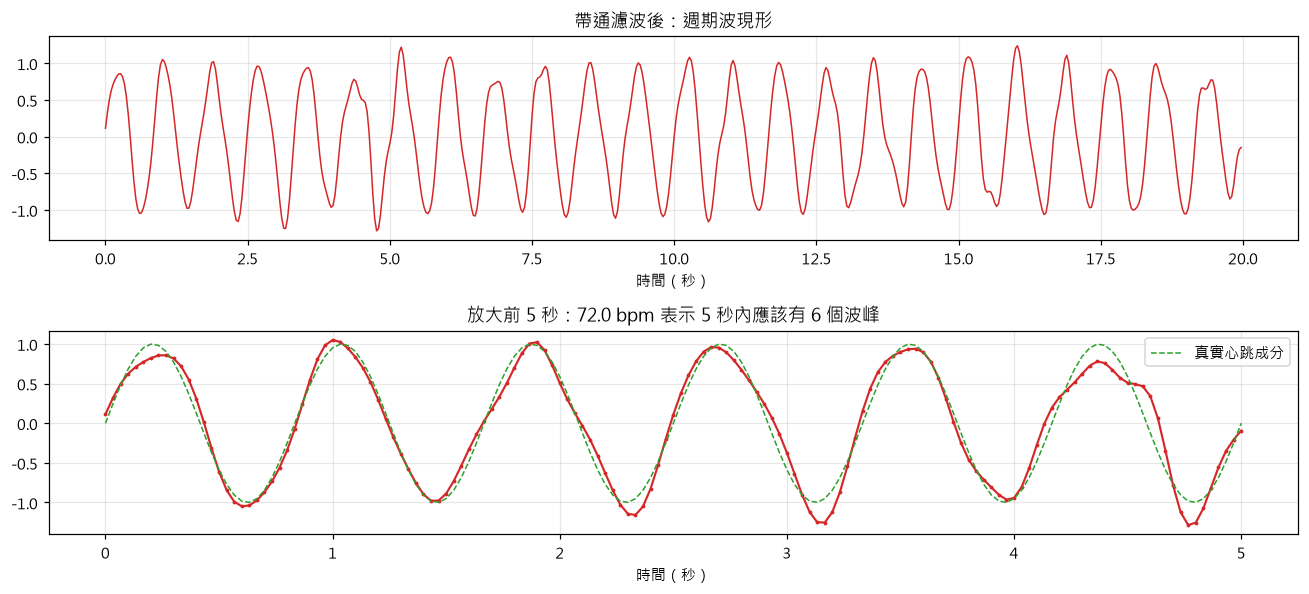

濾波後與真實心跳成分的相關係數：0.9796
（掐掉頭尾各 1 秒，filtfilt 的邊界效應集中在那裡）


In [5]:
filtered = su.bandpass_filter(detrended, FPS)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5))

axes[0].plot(t, filtered, lw=1.0, color="#d62728")
axes[0].set_title("帶通濾波後：週期波現形")
axes[0].set_xlabel("時間（秒）")
axes[0].grid(alpha=0.3)

# 放大前 5 秒，數一數波峰
window = t <= 5.0
axes[1].plot(t[window], filtered[window], lw=1.4, color="#d62728", marker=".", ms=3)
axes[1].plot(t[window], heartbeat[window], lw=1.0, ls="--", color="#2ca02c", label="真實心跳成分")
axes[1].set_title(f"放大前 5 秒：{TARGET_BPM} bpm 表示 5 秒內應該有 {TARGET_BPM / 60 * 5:.0f} 個波峰")
axes[1].set_xlabel("時間（秒）")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr = np.corrcoef(filtered[int(FPS):-int(FPS)], heartbeat[int(FPS):-int(FPS)])[0, 1]
print(f"濾波後與真實心跳成分的相關係數：{corr:.4f}")
print("（掐掉頭尾各 1 秒，filtfilt 的邊界效應集中在那裡）")

## 5. 第三步：功率頻譜與心率估計

用 Welch 方法：把訊號切成數段各自做 FFT 再平均。
分段平均會壓掉隨機雜訊造成的假峰，代價是頻譜解析度變差
（段長 10 秒 → 解析度 0.1 Hz = 6 bpm）。

**6 bpm 的格點間隔顯然不夠用**，所以 `estimate_heart_rate` 內部
再對峰值左右兩格做拋物線內插，把峰頂位置算到格點之間。
下面把這件事畫出來。

In [6]:
heart_rate, psd, freqs, snr = su.estimate_heart_rate(filtered, FPS)

error = abs(heart_rate - TARGET_BPM)
print(f"目標心率：{TARGET_BPM:.2f} bpm")
print(f"估算心率：{heart_rate:.2f} bpm")
print(f"誤差    ：{error:.2f} bpm")
print(f"SNR     ：{snr:.2f} dB（門檻 {config.RPPG_SNR_MIN} dB）")

band = (freqs >= config.RPPG_BAND_LOW) & (freqs <= config.RPPG_BAND_HIGH)
grid_peak = freqs[band][np.argmax(psd[band])]
print()
print(f"格點間隔      ：{freqs[1] - freqs[0]:.4f} Hz = {(freqs[1] - freqs[0]) * 60:.2f} bpm")
print(f"最大格點的頻率：{grid_peak:.4f} Hz = {grid_peak * 60:.2f} bpm（誤差 {abs(grid_peak * 60 - TARGET_BPM):.2f} bpm）")
print(f"內插後的頻率  ：{heart_rate / 60:.4f} Hz = {heart_rate:.2f} bpm（誤差 {error:.2f} bpm）")

目標心率：72.00 bpm
估算心率：71.94 bpm
誤差    ：0.06 bpm
SNR     ：6.27 dB（門檻 3.0 dB）

格點間隔      ：0.1000 Hz = 6.00 bpm
最大格點的頻率：1.2000 Hz = 72.00 bpm（誤差 0.00 bpm）
內插後的頻率  ：1.1990 Hz = 71.94 bpm（誤差 0.06 bpm）


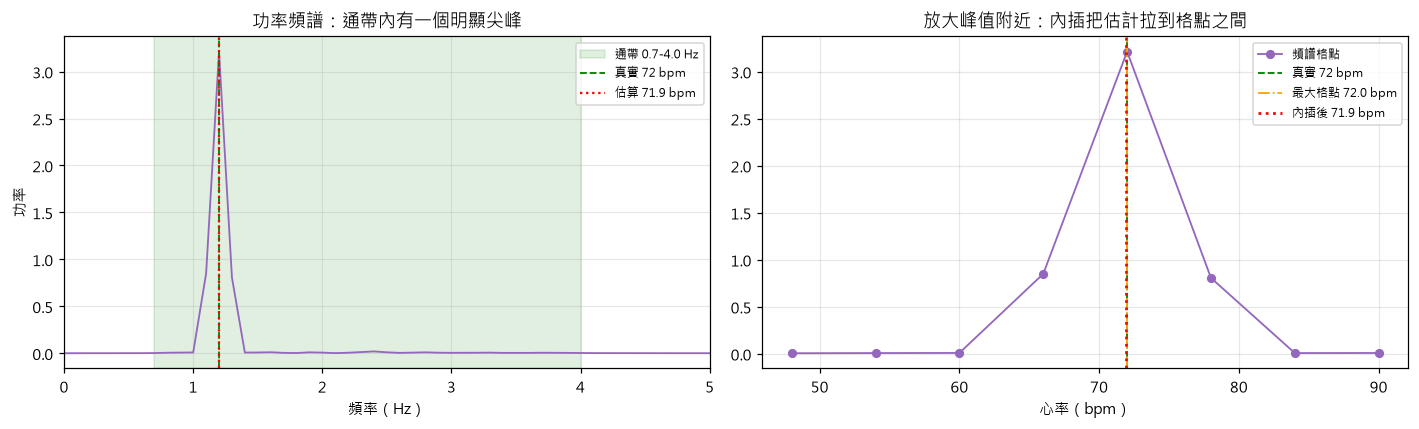

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(freqs, psd, lw=1.2, color="#9467bd")
axes[0].axvspan(config.RPPG_BAND_LOW, config.RPPG_BAND_HIGH, alpha=0.12,
                color="green", label=f"通帶 {config.RPPG_BAND_LOW}-{config.RPPG_BAND_HIGH} Hz")
axes[0].axvline(TARGET_BPM / 60, color="green", ls="--", lw=1.2, label=f"真實 {TARGET_BPM:.0f} bpm")
axes[0].axvline(heart_rate / 60, color="red", ls=":", lw=1.5, label=f"估算 {heart_rate:.1f} bpm")
axes[0].set_xlim(0, 5)
axes[0].set_title("功率頻譜：通帶內有一個明顯尖峰")
axes[0].set_xlabel("頻率（Hz）")
axes[0].set_ylabel("功率")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 放大峰值附近，看拋物線內插做了什麼
near = (freqs >= heart_rate / 60 - 0.4) & (freqs <= heart_rate / 60 + 0.4)
axes[1].plot(freqs[near] * 60, psd[near], "o-", lw=1.2, ms=5, color="#9467bd", label="頻譜格點")
axes[1].axvline(TARGET_BPM, color="green", ls="--", lw=1.2, label=f"真實 {TARGET_BPM:.0f} bpm")
axes[1].axvline(grid_peak * 60, color="orange", ls="-.", lw=1.2, label=f"最大格點 {grid_peak * 60:.1f} bpm")
axes[1].axvline(heart_rate, color="red", ls=":", lw=1.8, label=f"內插後 {heart_rate:.1f} bpm")
axes[1].set_title("放大峰值附近：內插把估計拉到格點之間")
axes[1].set_xlabel("心率（bpm）")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 三張圖並排對照

這就是 PLAN.md 階段 1 要求的那三張圖，只是用合成訊號跑的。
錄好真實影片後，同一組圖應該長得像這樣。

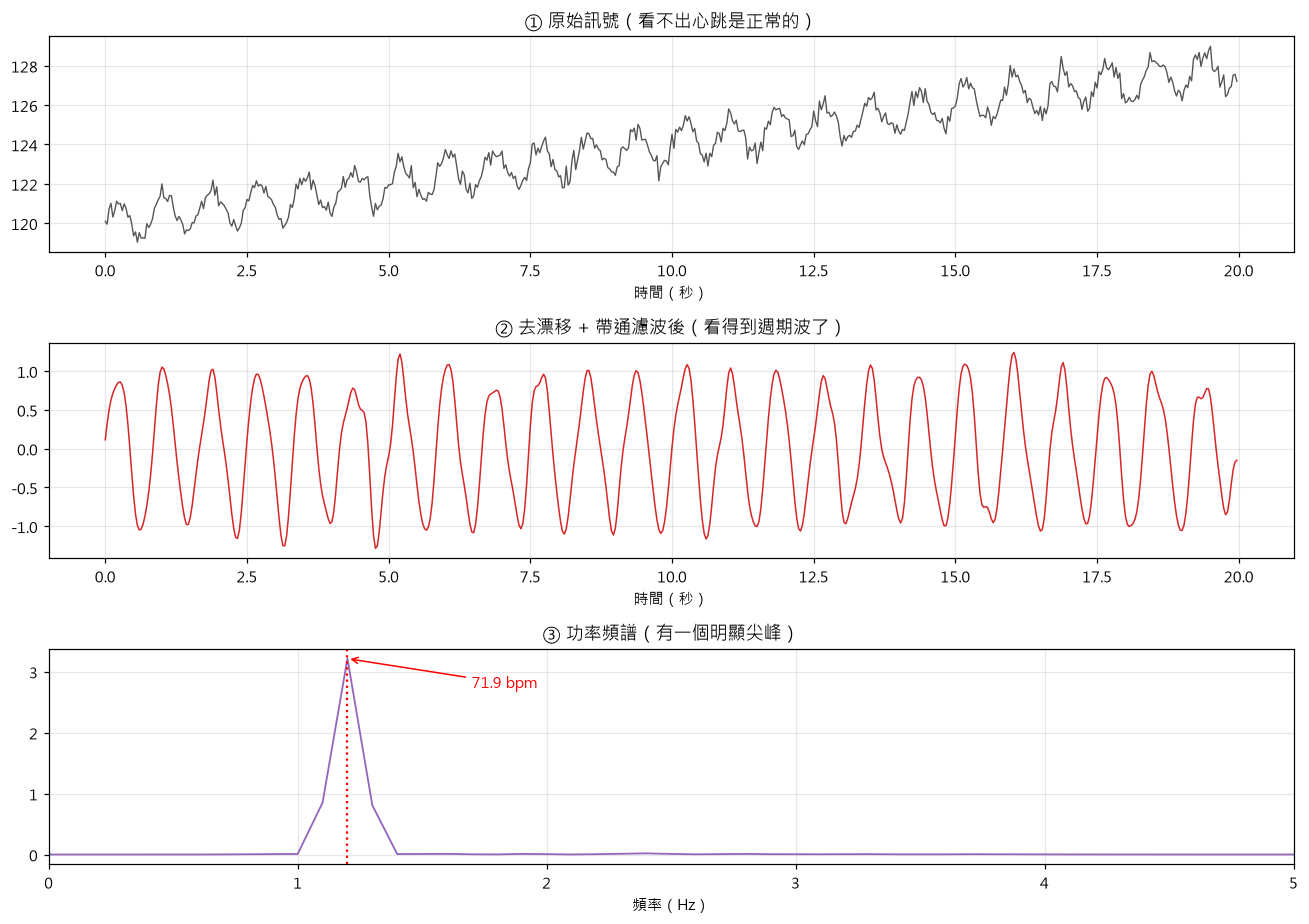

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8.5))

axes[0].plot(t, raw, lw=0.9, color="#555")
axes[0].set_title("① 原始訊號（看不出心跳是正常的）")
axes[0].set_xlabel("時間（秒）")
axes[0].grid(alpha=0.3)

axes[1].plot(t, filtered, lw=1.0, color="#d62728")
axes[1].set_title("② 去漂移 + 帶通濾波後（看得到週期波了）")
axes[1].set_xlabel("時間（秒）")
axes[1].grid(alpha=0.3)

axes[2].plot(freqs, psd, lw=1.2, color="#9467bd")
axes[2].axvline(heart_rate / 60, color="red", ls=":", lw=1.5)
axes[2].annotate(f"{heart_rate:.1f} bpm", xy=(heart_rate / 60, psd.max()),
                 xytext=(heart_rate / 60 + 0.5, psd.max() * 0.85),
                 arrowprops=dict(arrowstyle="->", color="red"), color="red")
axes[2].set_xlim(0, 5)
axes[2].set_title("③ 功率頻譜（有一個明顯尖峰）")
axes[2].set_xlabel("頻率（Hz）")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 整個生理範圍都要準

只有 72 bpm 準沒有意義 —— 可能只是剛好對上格點。
掃過 45 到 180 bpm，看誤差是否都在 2 bpm 以內。

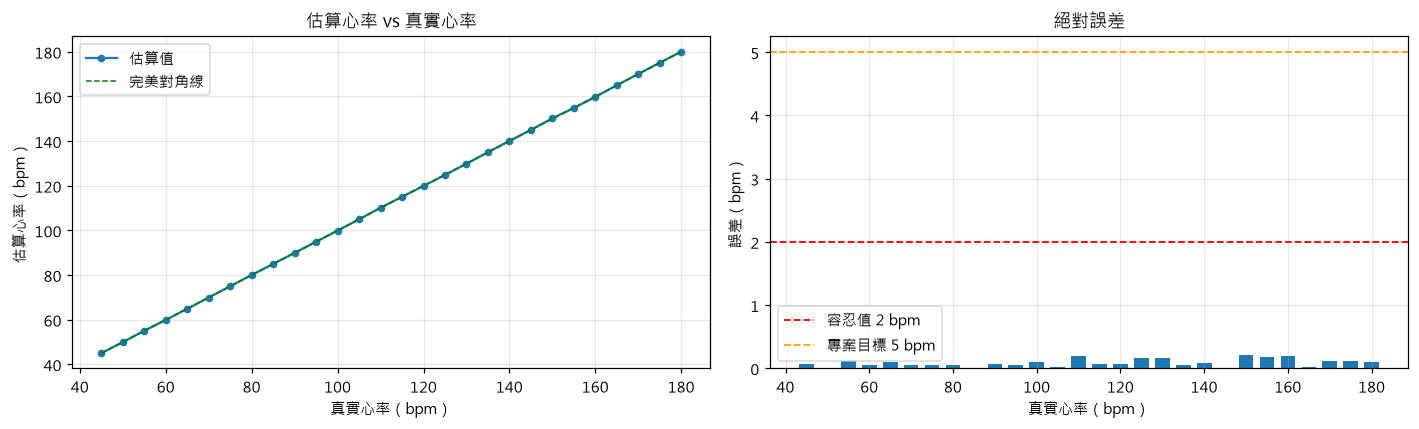

最大誤差：0.21 bpm
平均誤差：0.09 bpm
全部低於 2 bpm：True


In [9]:
test_bpms = np.arange(45, 185, 5, dtype=float)
estimated, errors = [], []

for bpm in test_bpms:
    r = np.random.default_rng(42)
    sig = (120.0
           + np.sin(2.0 * np.pi * (bpm / 60.0) * t)
           + 8.0 * t / DURATION_SEC
           + r.normal(0.0, 0.3, size=len(t)))
    hr, _, _, _ = su.estimate_heart_rate(su.bandpass_filter(su.detrend_signal(sig), FPS), FPS)
    estimated.append(hr)
    errors.append(abs(hr - bpm))

estimated = np.array(estimated)
errors = np.array(errors)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(test_bpms, estimated, "o-", ms=4, color="#1f77b4", label="估算值")
axes[0].plot(test_bpms, test_bpms, "--", color="green", lw=1, label="完美對角線")
axes[0].set_title("估算心率 vs 真實心率")
axes[0].set_xlabel("真實心率（bpm）")
axes[0].set_ylabel("估算心率（bpm）")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(test_bpms, errors, width=3.5, color="#1f77b4")
axes[1].axhline(2.0, color="red", ls="--", lw=1.2, label="容忍值 2 bpm")
axes[1].axhline(5.0, color="orange", ls="--", lw=1.2, label="專案目標 5 bpm")
axes[1].set_title("絕對誤差")
axes[1].set_xlabel("真實心率（bpm）")
axes[1].set_ylabel("誤差（bpm）")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最大誤差：{errors.max():.2f} bpm")
print(f"平均誤差：{errors.mean():.2f} bpm")
print(f"全部低於 2 bpm：{bool((errors < 2.0).all())}")

## 8. 雜訊到什麼程度會失效

這關係到 Demo 時「光線不足 → 人工複核」那一段的說法。
雜訊越大，頻譜的峰越不明顯，SNR 越低。

`config.RPPG_SNR_MIN = 3.0 dB` 就是判定 b 的門檻。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


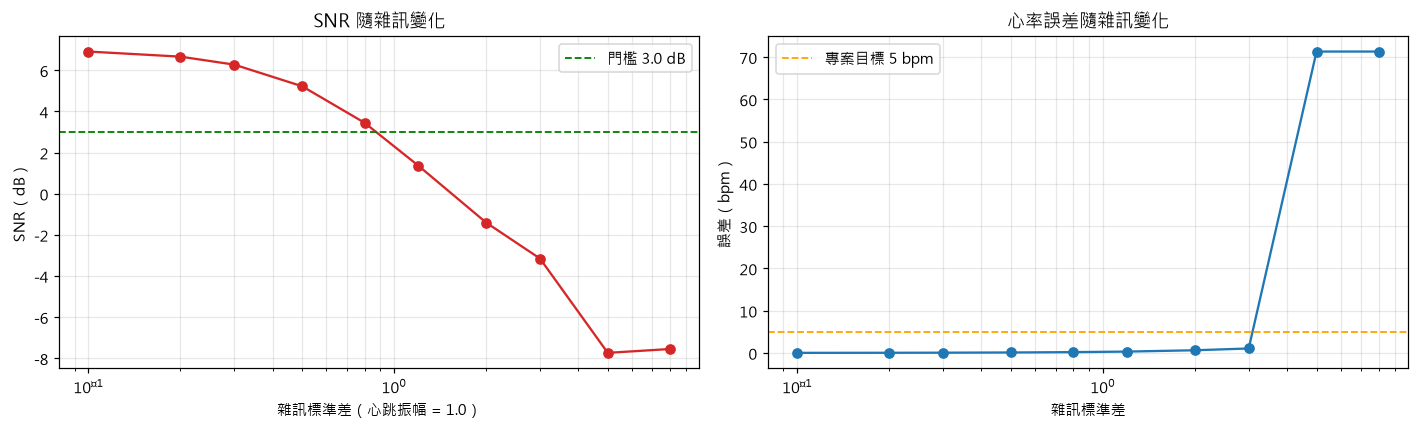

雜訊  0.1 → SNR   6.91 dB（通過），心率誤差  0.02 bpm
雜訊  0.2 → SNR   6.66 dB（通過），心率誤差  0.04 bpm
雜訊  0.3 → SNR   6.27 dB（通過），心率誤差  0.06 bpm
雜訊  0.5 → SNR   5.22 dB（通過），心率誤差  0.10 bpm
雜訊  0.8 → SNR   3.45 dB（通過），心率誤差  0.19 bpm
雜訊  1.2 → SNR   1.36 dB（不通過），心率誤差  0.32 bpm
雜訊  2.0 → SNR  -1.41 dB（不通過），心率誤差  0.63 bpm
雜訊  3.0 → SNR  -3.15 dB（不通過），心率誤差  1.05 bpm
雜訊  5.0 → SNR  -7.74 dB（不通過），心率誤差 71.33 bpm
雜訊  8.0 → SNR  -7.55 dB（不通過），心率誤差 71.33 bpm


In [10]:
noise_levels = np.array([0.1, 0.2, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0, 5.0, 8.0])
snr_values, hr_errors = [], []

for level in noise_levels:
    r = np.random.default_rng(42)
    sig = (120.0 + np.sin(2.0 * np.pi * (TARGET_BPM / 60.0) * t)
           + 8.0 * t / DURATION_SEC + r.normal(0.0, level, size=len(t)))
    hr, _, _, s = su.estimate_heart_rate(su.bandpass_filter(su.detrend_signal(sig), FPS), FPS)
    snr_values.append(s)
    hr_errors.append(abs(hr - TARGET_BPM))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(noise_levels, snr_values, "o-", color="#d62728")
axes[0].axhline(config.RPPG_SNR_MIN, color="green", ls="--", lw=1.2,
                label=f"門檻 {config.RPPG_SNR_MIN} dB")
axes[0].set_title("SNR 隨雜訊變化")
axes[0].set_xlabel("雜訊標準差（心跳振幅 = 1.0）")
axes[0].set_ylabel("SNR（dB）")
axes[0].legend()
axes[0].grid(alpha=0.3, which="both")

axes[1].semilogx(noise_levels, hr_errors, "o-", color="#1f77b4")
axes[1].axhline(5.0, color="orange", ls="--", lw=1.2, label="專案目標 5 bpm")
axes[1].set_title("心率誤差隨雜訊變化")
axes[1].set_xlabel("雜訊標準差")
axes[1].set_ylabel("誤差（bpm）")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

for level, s, e in zip(noise_levels, snr_values, hr_errors):
    verdict = "通過" if s >= config.RPPG_SNR_MIN else "不通過"
    print(f"雜訊 {level:>4.1f} → SNR {s:>6.2f} dB（{verdict}），心率誤差 {e:>5.2f} bpm")

## 9. 沒有心跳的時候呢

這是判定 b 存在的理由：不能什麼訊號丟進去都說「偵測到心跳」。

丟純高斯雜訊進去（模擬完全合成、沒有真實血流的臉），
`estimate_heart_rate` 仍然會回報一個「主頻」—— 頻帶內總有一格是最大的。
**但 SNR 會是負的**，判定 b 就會擋下來。

> 註：SNR 的算法與 PLAN.md 階段 2 那句「主峰功率 / 頻帶內其餘功率的平均」
> 不同。實測發現原算法對純雜訊會給出 3.5-8.0 dB，全部高於 3 dB 門檻，
> 等於沒有鑑別力。現在改用「主峰帶 + 二次諧波帶的能量 ÷ 帶內其餘能量」，
> 詳見 `signal_utils._band_snr` 的註解。

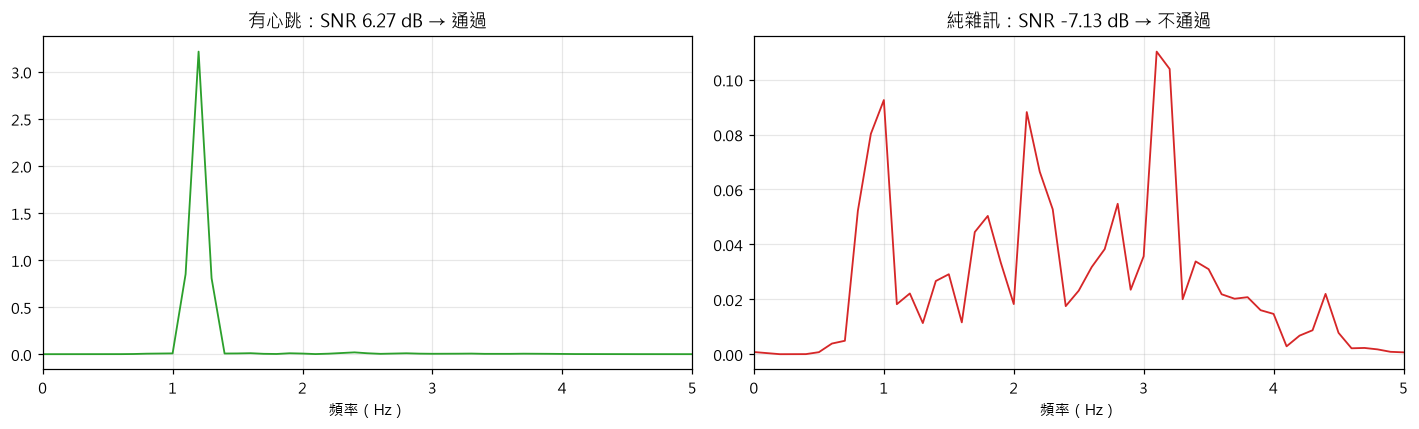

有心跳  ：主頻 71.9 bpm，SNR +6.27 dB
純雜訊  ：主頻 188.7 bpm，SNR -7.13 dB

兩者都給得出一個「主頻」數字，靠 SNR 才分得開 —— 這就是判定 b 的用途。

跑幾組不同的雜訊看穩不穩：
  seed=0  SNR  -6.53 dB  → 正確擋下
  seed=1  SNR  -4.91 dB  → 正確擋下
  seed=2  SNR  -6.70 dB  → 正確擋下
  seed=3  SNR  -5.77 dB  → 正確擋下
  seed=4  SNR  -8.48 dB  → 正確擋下
  seed=5  SNR  -8.12 dB  → 正確擋下


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

# 左：真訊號
hr_real, psd_real, freqs_real, snr_real = su.estimate_heart_rate(filtered, FPS)
axes[0].plot(freqs_real, psd_real, lw=1.2, color="#2ca02c")
axes[0].set_xlim(0, 5)
axes[0].set_title(f"有心跳：SNR {snr_real:.2f} dB → 通過")
axes[0].set_xlabel("頻率（Hz）")
axes[0].grid(alpha=0.3)

# 右：純雜訊
r = np.random.default_rng(7)
pure_noise = r.normal(0.0, 1.0, size=len(t))
hr_fake, psd_fake, freqs_fake, snr_fake = su.estimate_heart_rate(
    su.bandpass_filter(su.detrend_signal(pure_noise), FPS), FPS)
axes[1].plot(freqs_fake, psd_fake, lw=1.2, color="#d62728")
axes[1].set_xlim(0, 5)
axes[1].set_title(f"純雜訊：SNR {snr_fake:.2f} dB → 不通過")
axes[1].set_xlabel("頻率（Hz）")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"有心跳  ：主頻 {hr_real:.1f} bpm，SNR {snr_real:+.2f} dB")
print(f"純雜訊  ：主頻 {hr_fake:.1f} bpm，SNR {snr_fake:+.2f} dB")
print()
print("兩者都給得出一個「主頻」數字，靠 SNR 才分得開 —— 這就是判定 b 的用途。")

print()
print("跑幾組不同的雜訊看穩不穩：")
for seed in range(6):
    r = np.random.default_rng(100 + seed)
    n = r.normal(0.0, 1.0, size=len(t))
    _, _, _, s = su.estimate_heart_rate(su.bandpass_filter(su.detrend_signal(n), FPS), FPS)
    print(f"  seed={seed}  SNR {s:+6.2f} dB  → {'誤判' if s >= config.RPPG_SNR_MIN else '正確擋下'}")

## 10. §4.4 的輸出格式

最後確認 `spectrum` 重採樣成 64 點對應 0-4 Hz、`waveform` 300 點之後，
波形與峰值位置沒有跑掉。

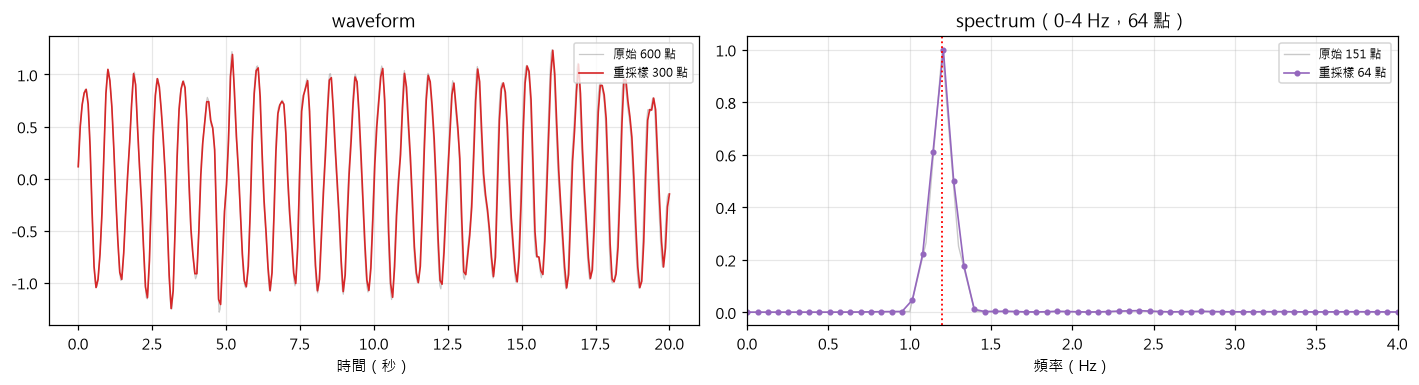

waveform 長度：300（config.RPPG_WAVEFORM_POINTS）
spectrum 長度：64（§4.4 規定 64）
重採樣後的峰值位置：72.4 bpm，原始 71.9 bpm


In [12]:
spectrum = su.resample_spectrum(freqs, psd, config.RPPG_SPECTRUM_POINTS, config.RPPG_SPECTRUM_MAX_HZ)
waveform = su.resample_curve(filtered, config.RPPG_WAVEFORM_POINTS)

grid = np.linspace(0, config.RPPG_SPECTRUM_MAX_HZ, config.RPPG_SPECTRUM_POINTS)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

axes[0].plot(t, filtered, lw=0.8, alpha=0.45, color="#888", label=f"原始 {len(filtered)} 點")
axes[0].plot(np.linspace(0, DURATION_SEC, len(waveform)), waveform, lw=1.1,
             color="#d62728", label=f"重採樣 {len(waveform)} 點")
axes[0].set_title("waveform")
axes[0].set_xlabel("時間（秒）")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(freqs, psd / psd.max(), lw=0.9, alpha=0.45, color="#888", label=f"原始 {len(psd)} 點")
axes[1].plot(grid, np.array(spectrum) / max(spectrum), "o-", ms=3, lw=1.1,
             color="#9467bd", label=f"重採樣 {len(spectrum)} 點")
axes[1].axvline(heart_rate / 60, color="red", ls=":", lw=1.2)
axes[1].set_xlim(0, config.RPPG_SPECTRUM_MAX_HZ)
axes[1].set_title("spectrum（0-4 Hz，64 點）")
axes[1].set_xlabel("頻率（Hz）")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"waveform 長度：{len(waveform)}（config.RPPG_WAVEFORM_POINTS）")
print(f"spectrum 長度：{len(spectrum)}（§4.4 規定 64）")
print(f"重採樣後的峰值位置：{grid[int(np.argmax(spectrum))] * 60:.1f} bpm，"
      f"原始 {heart_rate:.1f} bpm")

---

## 結論

| 項目 | 結果 |
|---|---|
| 合成 72 bpm 訊號的估算誤差 | 見第 5 節 |
| 45-180 bpm 全範圍最大誤差 | 見第 7 節 |
| 純雜訊會不會被誤判為有心跳 | 見第 9 節 |

**下一步**：照 PLAN.md 階段 1「B 的任務一」錄一段 20 秒的自己，
同時用手錶量心率，跑 `analyze_rppg()` 對答案。

錄影前先確認三件事：房間夠亮、鏡頭架穩、20 秒內盡量不要動。
跑完先看 `analyzer.draw_roi_overlay()` 產生的疊圖，
確認三個 ROI 真的落在額頭與雙頰上 —— ROI 框錯不會報錯，但數字全是假的。